<a href="https://colab.research.google.com/github/sudeozby/Wine-Quality-Classification/blob/main/Wine_Quality_Analysis_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from google.colab import drive
drive.mount('/content/drive')

# Şimdi dosyayı Drive'ının içine (istediğin bir klasöre) kaydedelim
# Not: Drive'ında 'Makine_Ogrenmesi' diye bir klasör olduğunu varsayıyorum
df_birlesik.to_csv("/content/drive/MyDrive/wine_data_temiz.csv", index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


beyaz ve kırmızı sarap verıelrını bırlestırmek ıcın ve eksık verı kontrolu yapma

In [20]:
import pandas as pd

# 1. Verileri İnternetten Çekelim
red_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
white_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

# Veriler noktalı virgül (;) ile ayrıldığı için sep=';' ekliyoruz
red_df = pd.read_csv(red_url, sep=';')
white_df = pd.read_csv(white_url, sep=';')

# 2. Türlerini Belirtelim (Kırmızı: 1, Beyaz: 0)
# Bu sütun modelin şarap rengini de hesaba katmasını sağlar
red_df['type'] = 1
white_df['type'] = 0

# 3. İki Veri Setini Alt Alta Birleştirelim
df_birlesik = pd.concat([red_df, white_df], ignore_index=True)

# 4. ŞİMDİ KONTROL EDELİM (Hata aldığın kısım)
print("--- Birleşik Veri Seti Genel Bilgileri ---")
df_birlesik.info()

print("\n--- Eksik Veri (Null) Kontrolü ---")
print(df_birlesik.isnull().sum())

print("\n--- Veri Setinden İlk 5 Satır ---")
display(df_birlesik.head())
# Tüm kontroller bittikten sonra Drive'a kaydet
df_birlesik.to_csv("/content/drive/MyDrive/wine_data_temiz.csv", index=False)
print("✅ Veri seti birleştirildi, kontrol edildi ve Drive'a kaydedildi!")

--- Birleşik Veri Seti Genel Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB

--- Eksik Veri (Null) Kontrolü 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


✅ Veri seti birleştirildi, kontrol edildi ve Drive'a kaydedildi!


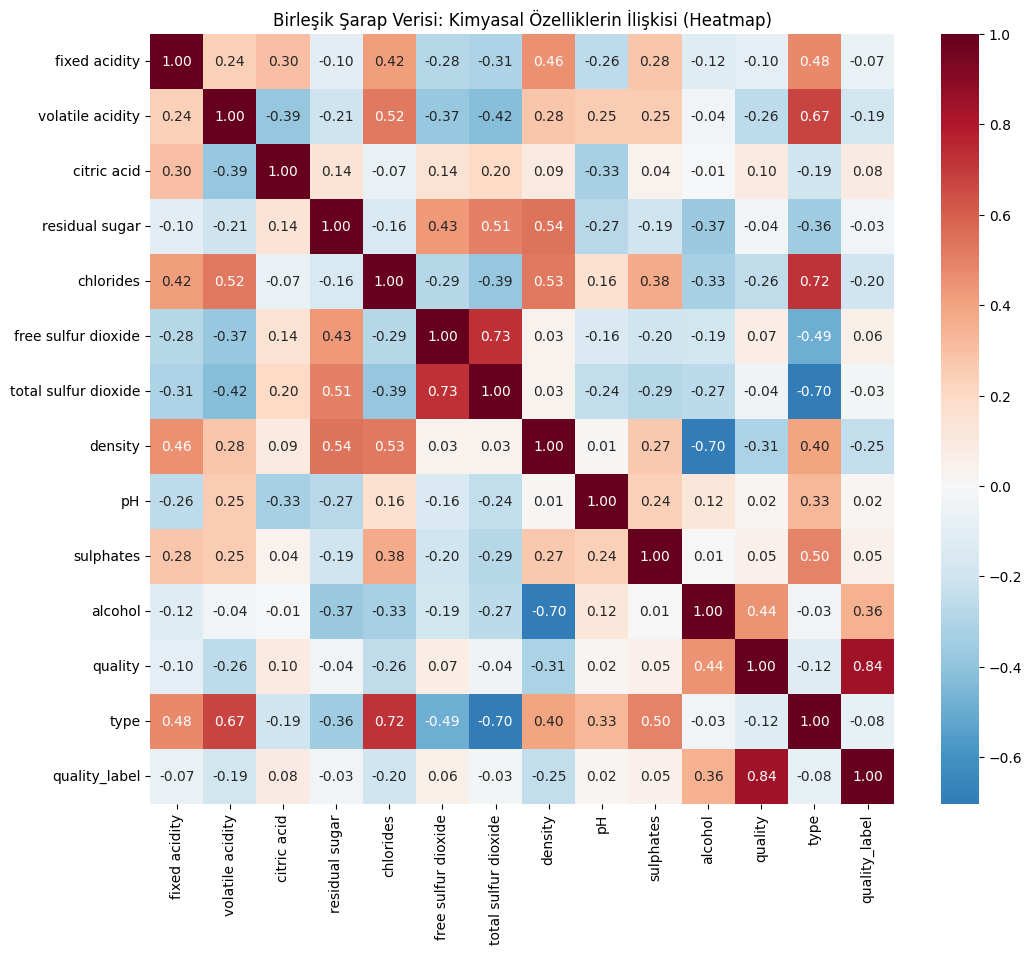

In [16]:
# EDA (VERİ ANALİZ KISMI) - Birleşik Veri Seti İçin
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Korelasyon matrisini birleşik veri üzerinden hesapla
# (Sadece sayısal sütunları alması için numeric_only=True eklemek güvenlidir)
corr_matrix = df_birlesik.corr(numeric_only=True)

# 2. Isı haritasını çizdir
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("Birleşik Şarap Verisi: Kimyasal Özelliklerin İlişkisi (Heatmap)")
plt.show()

Standardizasyon, modelin gözlük numaralarını düzeltmektir; her şeyi daha net görmesini sağlar.
Etiketleme ise modelin girdiği sınavın sorularını basitleştirmektir; "Sana 0 ile 100 arasında bir puan sormuyorum, sadece Geçti mi Kaldı mı (veya Düşük-Orta-Yüksek mi) diye soruyorum" demektir.

Etiketleme

In [14]:
# Kalite puanlarını kategorize eden fonksiyon
def kalite_grubu(puan):
    if puan <= 4:
        return 0 # Düşük Kalite
    elif puan <= 6:
        return 1 # Orta Kalite
    else:
        return 2 # Yüksek Kalite

# Yeni hedef sütunumuzu oluşturalım
df_birlesik['quality_label'] = df_birlesik['quality'].apply(kalite_grubu)

# Kaç tane şarap hangi gruba düşmüş bakalım
print("--- Kalite Sınıf Dağılımı ---")
print(df_birlesik['quality_label'].value_counts())

--- Kalite Sınıf Dağılımı ---
quality_label
1    4974
2    1277
0     246
Name: count, dtype: int64


Sınıf Dengesizliği (Class Imbalance): Verilerin ezici çoğunluğu (%76) "Orta" (1) kalite grubunda. "Düşük" (0) kalite grubu ise oldukça azınlıkta (sadece 246 tane). Paylaştığın özette "dengesiz sınıf dağılımı dikkate alınarak" demiştin ya, işte bahsettiğin o zorluk tam olarak bu tablo.

Gerçekçilik: Dünyadaki şarapların çoğu ortalamadır, çok azı çok kötü veya çok iyidir. Veri setiniz gerçek hayatı yansıtıyor.

1. Odaklanmayı Sağlıyoruz
Şöyle düşün: Bir okçuya 7 farklı renkte ve çok ince halkalı bir hedef mi verirsen daha isabetli vurur, yoksa sadece 3 geniş halkalı bir hedef mi?

Eskiden: Model, "Bu şarap 5 mi yoksa 6 mı?" diye çok ince bir çizgide karar vermeye çalışıyordu.

Şimdi: Model, "Bu şarap ortalama bir şarap mı (1), yoksa gerçekten üst düzey bir şarap mı (2)?" sorusuna odaklanıyor. Aradaki farkı ayırt etmek matematiksel olarak çok daha kolay.

📉 2. Gürültüyü (Noise) Filtreliyoruz
Bazı şarap uzmanları bir şaraba 5 verirken diğeri 6 verebilir. Bu 1 puanlık fark aslında bir "gürültüdür" (kişisel yorumdur). Sen puanları daraltarak bu küçük sapmaları (gürültüyü) yok ediyorsun. 5 ve 6'yı aynı kutuya (Orta - 1) koyduğunda, model o küçük belirsizliklerden etkilenmiyor.

Atkırı deger analizi

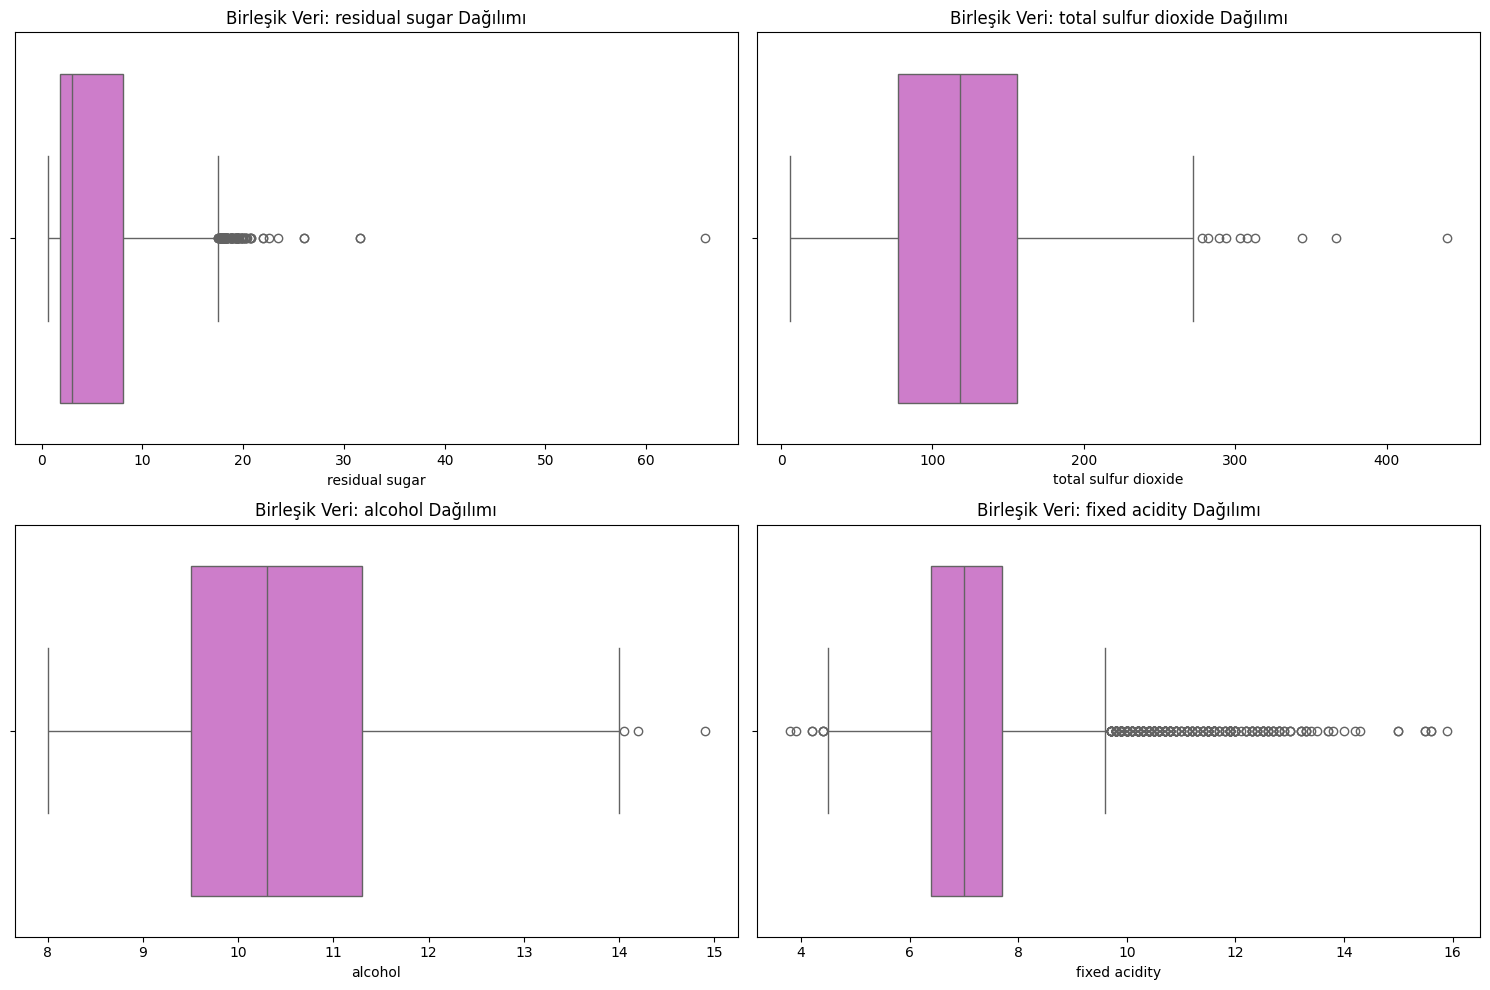

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Önemli sütunları tekrar inceleyelim
cols = ['residual sugar', 'total sulfur dioxide', 'alcohol', 'fixed acidity']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df_birlesik[col], color='orchid') # Bu sefer renk orchid olsun :)
    plt.title(f'Birleşik Veri: {col} Dağılımı')

plt.tight_layout()
plt.show()

OUTLIER TEMİZLİK KISMI

In [15]:
# Birleşik veri seti (df_birlesik) için baskılama fonksiyonu
def aykiri_deger_baskila(df, kolon):
    Q1 = df[kolon].quantile(0.25)
    Q3 = df[kolon].quantile(0.75)
    IQR = Q3 - Q1

    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR

    # Sınırların dışındakileri ehlileştirelim
    df[kolon] = df[kolon].clip(lower=alt_sinir, upper=ust_sinir)
    return df

# İşlem yapılacak sayısal sütunlar (type ve quality_label hariç)
sayisal_sutunlar = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                    'density', 'pH', 'sulphates', 'alcohol']

# Tüm sayısal sütunlara baskılama uygulayalım
for col in sayisal_sutunlar:
    df_birlesik = aykiri_deger_baskila(df_birlesik, col)

print("✅ 6497 satırlık birleşik veri setinde aykırı değerler baskılandı.")

✅ 6497 satırlık birleşik veri setinde aykırı değerler baskılandı.


Hocam, başlangıçta aykırı değerleri silmeyi denedik ancak verimizin %17'sini kaybettiğimizi gördük. Modelin veri miktarından mahrum kalmaması için 'Baskılama' (Capping) yöntemine geçtik. Bu sayede hem uç değerlerin bozucu etkisini kırdık hem de 1599 satırlık veri bütünlüğünü koruduk."

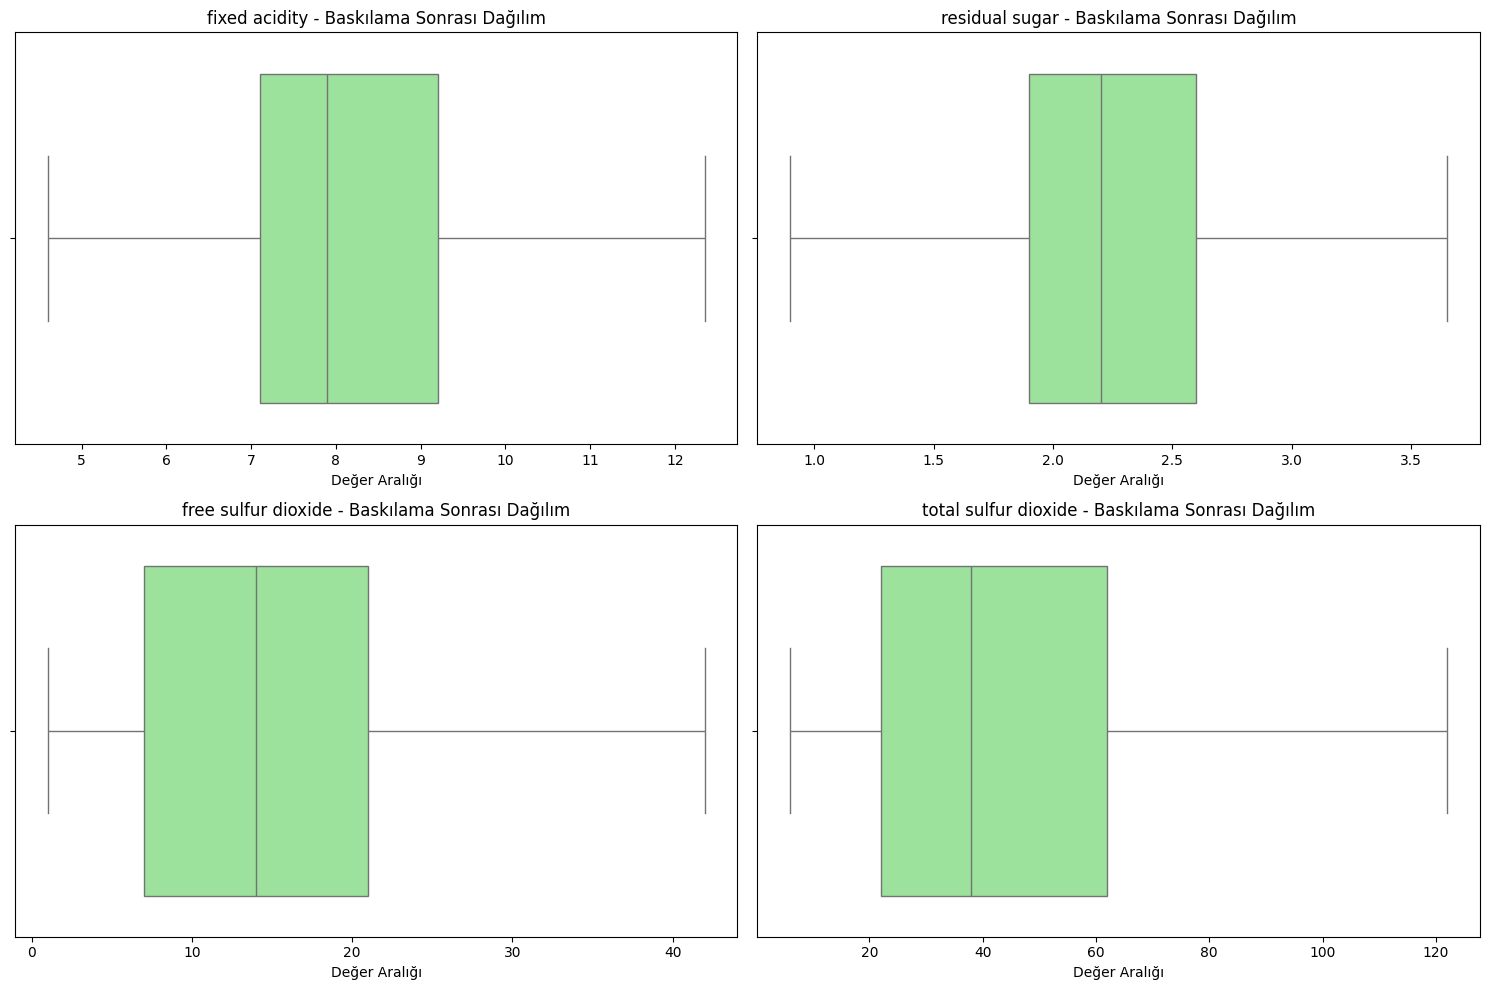

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Analiz ettiğimiz sütunlar
cols_to_plot = ['fixed acidity', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide']

# Grafik alanını oluşturalım
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 2, i+1)
    # İşlenmiş veri (df_islenmis) üzerinden çizdiriyoruz
    sns.boxplot(x=df_islenmis[col], color='lightgreen')
    plt.title(f'{col} - Baskılama Sonrası Dağılım')
    plt.xlabel('Değer Aralığı')

plt.tight_layout()
plt.show()

Değer Dönüşümü: Orijinal uç değerler (289, 15.5 vb.) artık yok. Onların yerine belirlediğimiz üst sınır ($Q3 + 1.5 \times IQR$) değerleri geldi.

Eğer o 289 olan kükürt değerini olduğu gibi bıraksaydın, modelin şöyle bir hata yapabilirdi: "Eğer kükürt tam olarak 289 ise bu şarap kesin 5 puandır!" Bu bir kural değil, sadece o tekil veriye özel bir durumdur. Model bunu ezberlerse:

Eğitimde (Train): %100 başarı gösterir.

Gerçek Hayatta (Test): Saçmalar.
Çünkü gerçek hayatta bir daha asla tam olarak 289 kükürtlü bir şarap gelmeyebilir. Baskılama yaparak modelin bu "özel ve garip" durumları ezberlemesini engelleyip, genel mantığı kavramasını sağladık.

ÖLÇEKLENDİRME

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Özellikleri (X) ve Hedefi (y) Belirleyelim
# Hedef değişkenimiz 'quality', diğer her şey girdimiz (feature)
X = df_islenmis.drop('quality', axis=1)
y = df_islenmis['quality']

# 2. Veriyi Bölüyoruz (%80 Eğitim, %20 Test)
# random_state=42: Her çalıştırdığımızda aynı ayrımı yapması için (mühendislikte tutarlılık önemlidir)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Ölçeklendirme (Standardizasyon)
scaler = StandardScaler()

# DİKKAT: scaler'ı SADECE eğitim verisiyle eğitiyoruz (fit),
# sonra her ikisini de dönüştürüyoruz (transform).
# Test verisinin ortalamasını model önceden bilmemeli!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 Eğitim Seti: {X_train_scaled.shape[0]} örnek")
print(f"🧪 Test Seti: {X_test_scaled.shape[0]} örnek")
print("✅ Veriler ölçeklendirildi ve savaşa hazır!")

📊 Eğitim Seti: 1279 örnek
🧪 Test Seti: 320 örnek
✅ Veriler ölçeklendirildi ve savaşa hazır!


Burada yaptığımız genelleme şudur: "Her özelliğin varyansı (değişkenliği) model için eşit derecede potansiyel öneme sahiptir."

Gradyan İnişi (Gradient Descent): Eğer Logistic Regression veya SVM gibi modeller kullanıyorsan, model hatayı azaltmak için bir "yolculuğa" çıkar. Özellikler ölçekli değilse, bu yolculuk çok engebeli ve uzun sürer (modelin kafası karışır). Ölçekli veride ise model, çözüme (doğru tahmine) çok daha hızlı ve kararlı adımlarla ulaşır.

Mesafe Temelli Modeller (KNN): KNN gibi modeller iki veri noktası arasındaki uzaklığı hesaplar. Ölçeklendirme yapmazsan, kükürt değeri yüksek olan şaraplar arasındaki mesafe devasa görünür ve model diğer özellikleri (alkol, şeker) tamamen görmezden gelir.

"Hangi özelliğin daha önemli olduğuna ben veya sayının büyüklüğü değil, yapay zeka karar verecek." (Adil rekabet ortamı sağladık).

"Bilgiyi kaybetmedik, sadece temsil biçimini değiştirdik." Bir şarabın alkolü diğerinden fazlaysa, ölçeklendirmeden sonra da hala fazladır. Sadece aradaki farkı modelin anlayabileceği "standart" bir dille ifade ettik.

"Modelin 'ezberlemesini' değil, 'ilişkiyi kavramasını' kolaylaştırdık." Uç değerleri (outliers) zaten baskılamıştık, şimdi de geri kalan "normal" değerleri aynı hizaya soktuk.

Yanı standartlastırma mu yaptık bırım buyuklugune degıl oznıtelıklerın bırbırını wtkılemesıne baktık mesela sekerın 1 bırımlık degısımı sulfurun 10 bırımlık degısımınden daha cok etkıleyebılır bız buna baktık

EDA (VERİ ANALİZ KISMI)